# Community Detection on Fashion-MNIST  
### Unsupervised Label Propagation on a k-NN Graph

In the semi-supervised **Label Propagation** notebook, Fashion-MNIST images were
connected through a k-nearest-neighbor (k-NN) similarity graph and a small subset
of labels was provided.

In this notebook, we use **the same dataset and the same graph construction**, but
**remove all label information during training**.  
The goal is to discover **communities of visually similar images** purely from
graph structure.

---

## Goals

- Load and preprocess Fashion-MNIST images.
- Construct a k-NN similarity graph in feature space.
- Apply **unsupervised label propagation** to detect communities.
- Visualize the discovered structure using PCA.
- Interpret communities using true labels *only for analysis*.
- Compare community detection with semi-supervised label propagation.


## 1. Load Fashion-MNIST


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

from rice_ml.unsupervised_learning import label_propagation_communities

X, y = fetch_openml(
    "Fashion-MNIST",
    version=1,
    return_X_y=True,
    as_frame=False
)

X = X.astype(float)
y = y.astype(int)

## 2. Subsample the dataset

In [ ]:
rng = np.random.default_rng(42)

n_samples = 500  # keep small and defensible
idx = rng.choice(X.shape[0], size=n_samples, replace=False)

X_sub = X[idx]
y_sub = y[idx]   # for interpretation only


Fashion-MNIST contains 60,000 training images. Applying graph-based community
detection to the full dataset would require constructing and storing a very large
k-nearest-neighbor graph, which is computationally expensive and unnecessary for
the goals of this experiment.

Since the objective here is **structure discovery and qualitative analysis**, we
work with a random subset of the data:

- Large enough to contain diverse classes and meaningful neighborhood structure.
- Small enough to allow efficient graph construction, iterative label propagation,
  and clear visualization.

We therefore randomly select **500 images** from the full dataset. A fixed random
seed is used to ensure reproducibility. The true labels of these samples are kept
only for **post hoc interpretation** and are never used during training.


## 3. Build the k-NN similarity graph

In [4]:
X_sub = X_sub / 255.0


In [5]:
k = 10

nn = NearestNeighbors(n_neighbors=k + 1, metric="euclidean")
nn.fit(X_sub)
distances, neighbors = nn.kneighbors(X_sub)


## 4. Community detection via unsupervised label propagation


In [6]:
n = X_sub.shape[0]
A = np.zeros((n, n), dtype=float)

for i in range(n):
    for j, d in zip(neighbors[i, 1:], distances[i, 1:]):
        A[i, j] = np.exp(-d)   # weighted edge
        A[j, i] = A[i, j]     # make symmetric


In [7]:
communities = label_propagation_communities(
    A,
    max_iter=200,
    seed=42
)

n_communities = len(np.unique(communities))
n_communities


46

## 5. Visualization of discovered communities


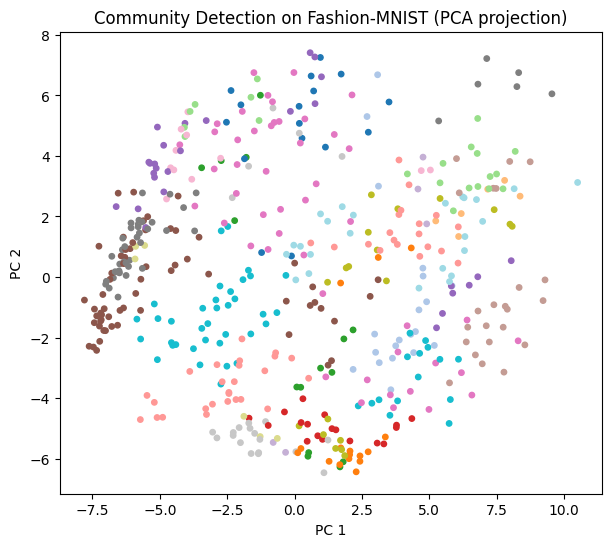

In [8]:
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_sub)

plt.figure(figsize=(7, 6))
scatter = plt.scatter(
    X_2d[:, 0],
    X_2d[:, 1],
    c=communities,
    cmap="tab20",
    s=15
)
plt.title("Community Detection on Fashion-MNIST (PCA projection)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()


## Interpretation of the PCA visualization

The figure above shows a 2D PCA projection of the Fashion-MNIST subset, where each
point represents an image and colors indicate the **community assignments**
discovered by unsupervised label propagation.

Several patterns are worth noting:

- The algorithm identifies **multiple distinct communities**, many of which form
  spatially coherent regions in PCA space.
- Communities tend to align with **local density structure**: points that are
  close in feature space and share similar neighbors in the k-NN graph are grouped
  together.
- Some communities are compact and well-separated, while others are more diffuse,
  reflecting overlap between visually similar clothing categories.
- Unlike supervised or semi-supervised learning, these colors do **not correspond
  to predefined Fashion-MNIST classes**. Instead, they represent clusters that
  emerge naturally from the geometry of the data.

Overall, the visualization confirms that unsupervised label propagation is able to
recover meaningful structure from the k-NN graph without using any label
information during training.



## 6. Experimental setup and evaluation protocol

Community detection is performed in a fully **unsupervised** manner:

- True Fashion-MNIST labels are **not used** to construct the graph.
- Labels are **not used** during the propagation algorithm.
- The algorithm is not informed of the number of classes.

Ground-truth labels are examined **only after training** to help interpret the
semantic meaning of the discovered communities.


In [9]:
from collections import Counter

for c in np.unique(communities):
    idx_c = np.where(communities == c)[0]
    label_counts = Counter(y_sub[idx_c])
    print(f"Community {c}: {label_counts}")


Community 0: Counter({np.int64(9): 2})
Community 1: Counter({np.int64(9): 8, np.int64(5): 1})
Community 2: Counter({np.int64(8): 5})
Community 3: Counter({np.int64(8): 2})
Community 4: Counter({np.int64(0): 11, np.int64(6): 7})
Community 5: Counter({np.int64(0): 3})
Community 6: Counter({np.int64(1): 13})
Community 7: Counter({np.int64(6): 2, np.int64(4): 2})
Community 8: Counter({np.int64(6): 2})
Community 9: Counter({np.int64(3): 4, np.int64(4): 2})
Community 10: Counter({np.int64(8): 5})
Community 11: Counter({np.int64(1): 4})
Community 12: Counter({np.int64(4): 6, np.int64(6): 4, np.int64(2): 3, np.int64(8): 1})
Community 13: Counter({np.int64(9): 7})
Community 14: Counter({np.int64(1): 2})
Community 15: Counter({np.int64(3): 16})
Community 16: Counter({np.int64(6): 6, np.int64(4): 6, np.int64(2): 4, np.int64(3): 1, np.int64(0): 1})
Community 17: Counter({np.int64(3): 12, np.int64(6): 6, np.int64(0): 6, np.int64(1): 3})
Community 18: Counter({np.int64(9): 9, np.int64(7): 6, np.int6

## Interpreting discovered communities using true labels

Although community detection is performed **without using any labels**, we can
inspect the true Fashion-MNIST labels *after training* to understand what each
community represents.

Fashion-MNIST provides ground-truth class labels encoded as integers:

- 0 → T-shirt/top  
- 1 → Trouser  
- 2 → Pullover  
- 3 → Dress  
- 4 → Coat  
- 5 → Sandal  
- 6 → Shirt  
- 7 → Sneaker  
- 8 → Bag  
- 9 → Ankle boot  

The printed outputs above report, for each discovered community, a `Counter`
showing how many images of each true class (by integer label) are contained in
that community.

From these results, we observe that:

- Many communities are **dominated by a single class** (for example, communities
  containing mostly label `1` correspond to *trousers*, while communities dominated
  by label `8` correspond to *bags*), indicating strong visual similarity within
  those categories.
- Some communities contain a **mixture of related classes**, especially among
  upper-body garments such as *T-shirt/top* (`0`), *shirt* (`6`), *pullover* (`2`),
  and *coat* (`4`).
- This mixing reflects genuine ambiguity in Fashion-MNIST rather than a failure
  of the algorithm, as these categories share similar silhouettes and textures.

Importantly, the algorithm was never told how many classes exist or what they mean.
The fact that several communities align closely with semantic Fashion-MNIST
categories demonstrates that the k-NN graph captures meaningful visual
relationships in the data.


## Why does the algorithm discover many communities?

Unsupervised label propagation does **not** fix the number of communities in advance.
Instead, the final number of communities emerges from:

- The **local connectivity** of the k-NN graph,
- The choice of `k` (number of neighbors),
- The intrinsic structure of the data manifold.

With a relatively small neighborhood size (`k = 10`) and a diverse image dataset,
the graph naturally fragments into multiple local clusters. Some of these clusters
correspond closely to semantic classes, while others capture finer-grained visual
variations (e.g., different shoe styles or shirt shapes).


## Conclusions

**Key takeaways:**

- The algorithm discovers multiple communities without any prior knowledge of
  class labels or the number of groups.
- Several communities align closely with semantic Fashion-MNIST classes, indicating
  that the k-NN graph captures meaningful visual similarity.
- Ambiguous clothing categories naturally lead to mixed communities, reflecting
  intrinsic overlap in the data rather than algorithmic failure.
- Compared to semi-supervised label propagation, community detection focuses on
  **understanding structure** rather than **predictive accuracy**.

Together with the semi-supervised Label Propagation notebook, this experiment
demonstrates how the same graph-based framework can support fundamentally different
machine learning objectives depending on the availability of supervision.